In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
from src.analysis.did_event_study import run_did, pre_trend_check

panel = pd.read_csv('../data/processed/panel_dataset.csv')
panel['log_enrollment'] = np.log(panel['total_enrollment'])

# Pilot: SH004, US-China trade war, restricted to pre-COVID window
print("=== Pre-trend check ===")
pre_check = pre_trend_check(panel, ['China'], shock_year=2018, outcome_col='log_enrollment', pre_window_start=2010)
print(f"Coefficient: {pre_check['coefficient']:.4f}, p-value: {pre_check['p_value']:.4f}")

print("\n=== Main DiD estimate ===")
result = run_did(panel, ['China'], shock_year=2018, outcome_col='log_enrollment',
                  window_start=2010, window_end=2019)
print(f"Coefficient: {result['coefficient']:.4f}")
print(f"P-value: {result['p_value']:.4f}")
print(f"95% CI: {result['conf_int']}")

=== Pre-trend check ===
Coefficient: 0.2562, p-value: 0.0002

=== Main DiD estimate ===
Coefficient: 0.2470
P-value: 0.0000
95% CI: [0.13662682704582496, 0.3572916022674925]


In [2]:
narrow_control = ['India', 'South Korea', 'Vietnam']

print("=== Pre-trend check (narrow control group) ===")
pre_check = pre_trend_check(panel, ['China'], shock_year=2018, outcome_col='log_enrollment', pre_window_start=2010)
# note: need to filter panel to just China + narrow_control before calling
narrow_panel = panel[panel['country'].isin(['China'] + narrow_control)]
pre_check = pre_trend_check(narrow_panel, ['China'], shock_year=2018, outcome_col='log_enrollment', pre_window_start=2010)
print(f"Coefficient: {pre_check['coefficient']:.4f}, p-value: {pre_check['p_value']:.4f}")

print("\n=== Main DiD estimate (narrow control group) ===")
result = run_did(narrow_panel, ['China'], shock_year=2018, outcome_col='log_enrollment',
                  window_start=2010, window_end=2019)
print(f"Coefficient: {result['coefficient']:.4f}")
print(f"P-value: {result['p_value']:.4f}")
print(f"95% CI: {result['conf_int']}")

=== Pre-trend check (narrow control group) ===
Coefficient: 0.2491, p-value: 0.2553

=== Main DiD estimate (narrow control group) ===
Coefficient: 0.1859
P-value: 0.3644
95% CI: [-0.22799535535277077, 0.5997396003971778]


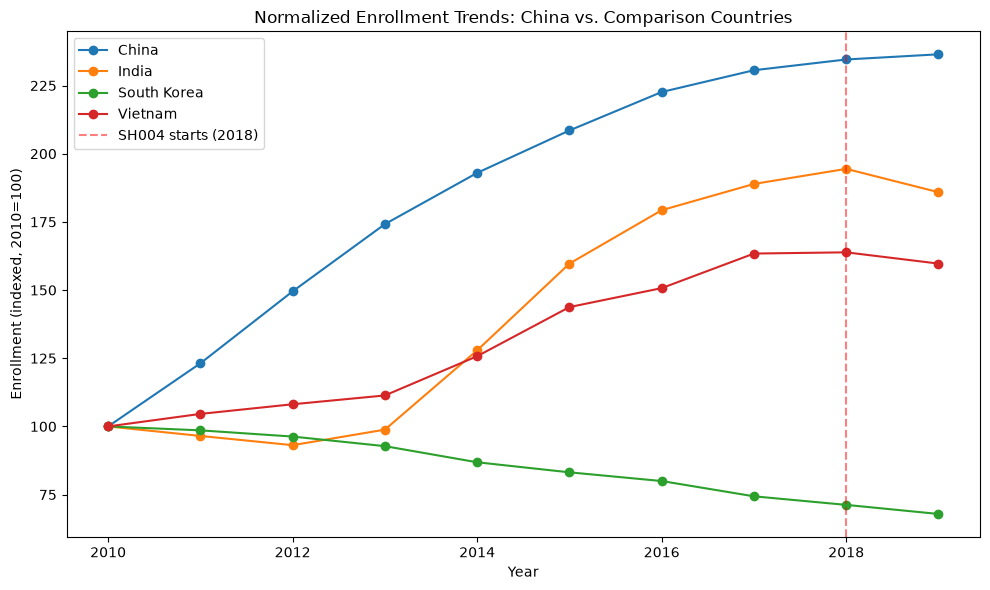

In [3]:
import matplotlib.pyplot as plt

check_countries = ['China', 'India', 'South Korea', 'Vietnam']
fig, ax = plt.subplots(figsize=(10, 6))
for country in check_countries:
    sub = panel[(panel.country == country) & (panel.panel_year.between(2010, 2019))].sort_values('panel_year')
    # normalize to 2010 = 100 so trends are comparable despite scale differences
    normalized = sub['total_enrollment'] / sub['total_enrollment'].iloc[0] * 100
    ax.plot(sub['panel_year'], normalized, marker='o', label=country)

ax.axvline(x=2018, color='red', linestyle='--', alpha=0.5, label='SH004 starts (2018)')
ax.set_xlabel('Year')
ax.set_ylabel('Enrollment (indexed, 2010=100)')
ax.set_title('Normalized Enrollment Trends: China vs. Comparison Countries')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
shocks = pd.read_csv('../data/raw/shock_catalog.csv')
print(shocks[shocks['shock_id'].isin(['SH001', 'SH002', 'SH003', 'SH010'])][['shock_id', 'shock_name', 'start_date', 'end_date', 'affected_countries']].to_string(index=False))

shock_id                                                shock_name start_date   end_date                                affected_countries
   SH001            September 11 attacks and Afghanistan War onset 2001-09-11 2021-08-30                                       Afghanistan
   SH002                                            Iraq War onset 2003-03-20 2011-12-18                                              Iraq
   SH003                  Post-9/11 visa/SEVIS security tightening 2002-05-14 2003-01-30                                     All countries
   SH010 NSEERS (National Security Entry-Exit Registration System) 2002-09-11 2011-04-28 25 Countries (primarily Middle East/North Africa)


In [5]:
nseers_treated = ['Afghanistan', 'Iran', 'Iraq']
nseers_control = ['India', 'South Korea', 'Vietnam']

nseers_panel = panel[panel['country'].isin(nseers_treated + nseers_control)]

print("=== Pre-trend check (SH010, NSEERS) ===")
pre_check = pre_trend_check(nseers_panel, nseers_treated, shock_year=2002, outcome_col='log_enrollment', pre_window_start=2000)
print(pre_check)

print("\n=== Main DiD estimate (SH010, NSEERS) ===")
result = run_did(nseers_panel, nseers_treated, shock_year=2002, outcome_col='log_enrollment',
                  window_start=2000, window_end=2011)
print(f"Coefficient: {result['coefficient']:.4f}")
print(f"P-value: {result['p_value']:.4f}")
print(f"95% CI: {result['conf_int']}")

=== Pre-trend check (SH010, NSEERS) ===
{'warning': 'Not enough pre-period years for a meaningful pre-trend check'}

=== Main DiD estimate (SH010, NSEERS) ===
Coefficient: 0.1180
P-value: 0.6981
95% CI: [-0.48851080266836266, 0.7244397292563551]
